In [1]:
from nrem_analysis.constant import RAW_DIR, PROCESSED_DIR, INTERIM_DIR, MOUSE_IDS_DUAL
from nrem_analysis.utils import load_tsg, plot_intervals

from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pynapple as nap

### Load sleep states as IntervalSet object

Processing 100b
Saving sleep states to D:\common_datasets\ucsf\processed\dual\100b\sleep.npz
Processing 102b
Saving sleep states to D:\common_datasets\ucsf\processed\dual\102b\sleep.npz
Processing 103c
Saving sleep states to D:\common_datasets\ucsf\processed\dual\103c\sleep.npz
Processing 106b
Saving sleep states to D:\common_datasets\ucsf\processed\dual\106b\sleep.npz
Processing 107b
Saving sleep states to D:\common_datasets\ucsf\processed\dual\107b\sleep.npz
Processing 110b
Saving sleep states to D:\common_datasets\ucsf\processed\dual\110b\sleep.npz
Processing 111b
Saving sleep states to D:\common_datasets\ucsf\processed\dual\111b\sleep.npz
Processing 99b
Dropping: 1 interval(s)
     start    end state
192  40918  40918   rem
Saving sleep states to D:\common_datasets\ucsf\processed\dual\99b\sleep.npz


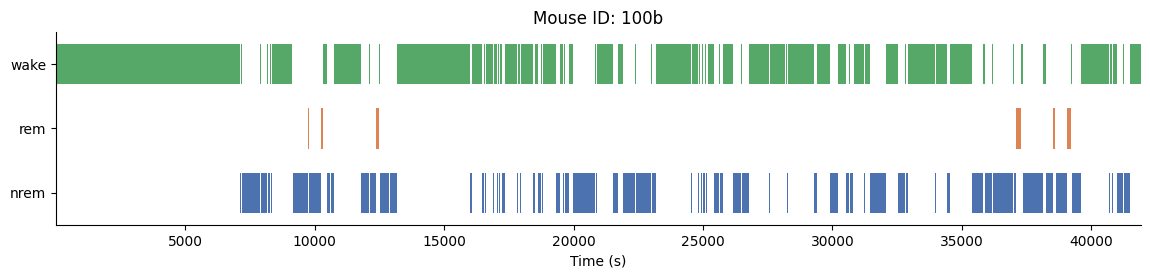

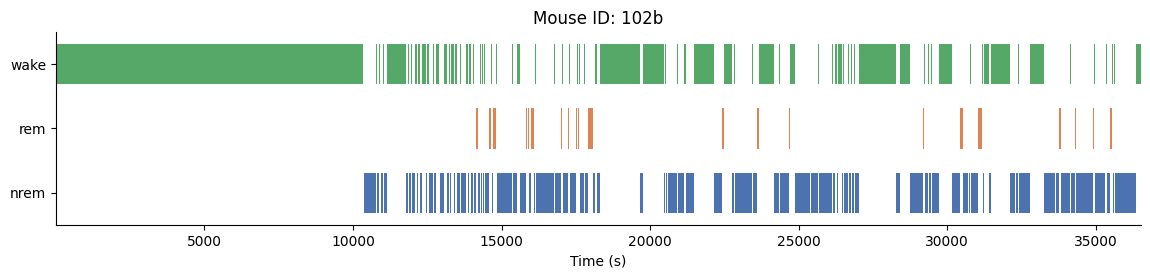

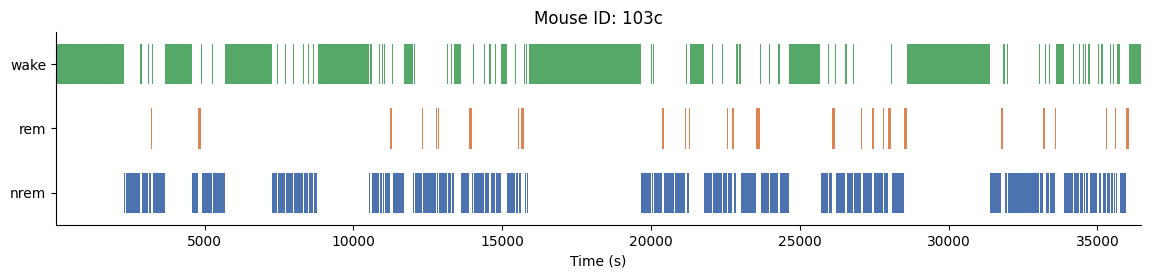

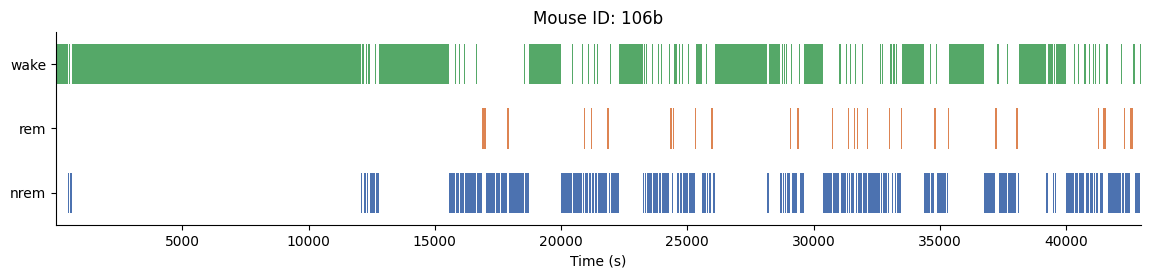

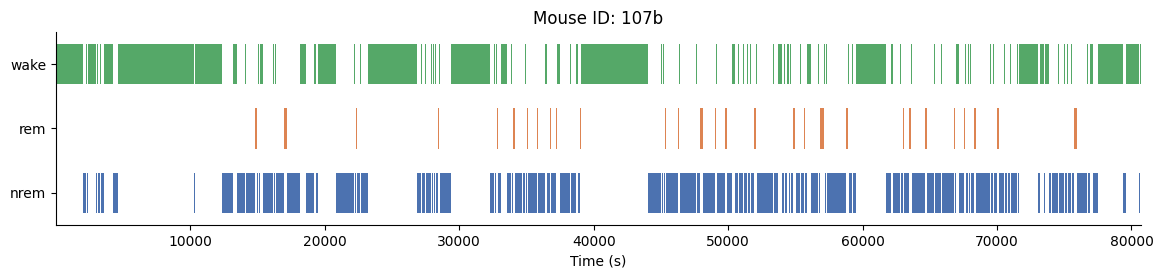

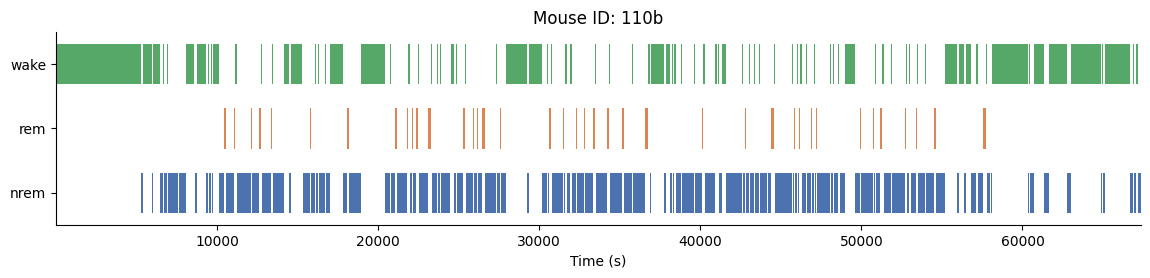

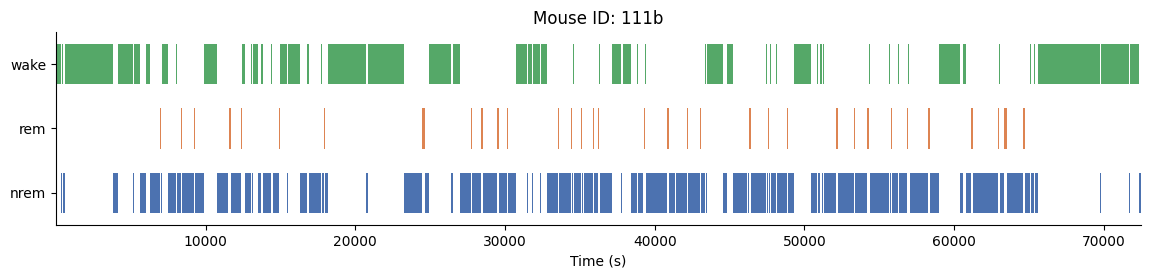

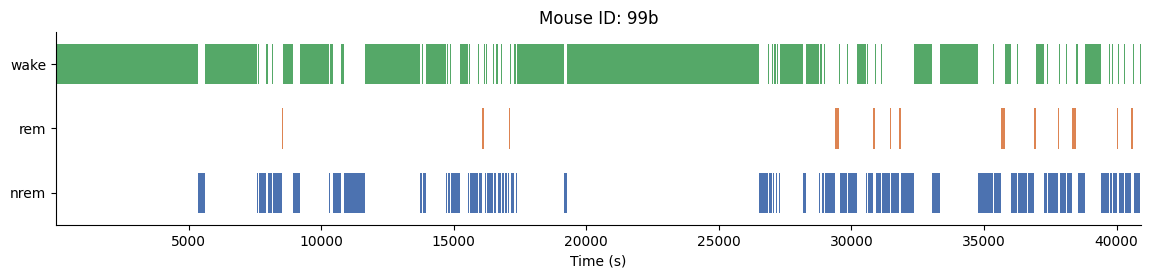

In [2]:
input_dir = RAW_DIR / "dual"
output_dir = PROCESSED_DIR / "dual"
states = ["wake", "nrem", "rem"]
for p in input_dir.iterdir():
    if p.name not in MOUSE_IDS_DUAL:
        continue
    print(f"Processing {p.name}")
    df = []
    for state in states:
        data = loadmat(p / f"{state}.mat")[state].squeeze()
        df.append(pd.DataFrame(
            {
            'start': data[:,0], 
            'end': data[:,1],
            'state': state
            }))
    df = pd.concat(df).sort_values('start').reset_index(drop=True)
    idx = np.where((df['end'] - df['start']) == 0)[0]
    if len(idx) > 0:
        print(f"Dropping: {len(idx)} interval(s)")
        print(df.iloc[idx])
        df.drop(idx, inplace=True)
        df.reset_index(drop=True, inplace=True)
    
    sleep = nap.IntervalSet(start=df['start'], end=df['end'],
                            time_units='s',
                            metadata={'state': df['state']}
                            )    
    output = output_dir / p.name / 'sleep.npz'
    output.parent.mkdir(parents=True, exist_ok=True)

    print(f"Saving sleep states to {output}")
    sleep.save(output)
    plot_intervals(sleep, column='state', title=f"Mouse ID: {p.name}")

### Load SC shanks and extract turn modulated cells

In [3]:
input_dir = RAW_DIR / "dual"
output_dir = PROCESSED_DIR / "dual"

# Single SC shank for each mouse
shank_sc = [3, 3, 3, 3, 3, 3, 5, 3]

for i, mouse_id in enumerate(MOUSE_IDS_DUAL):
    turn_uid = loadmat(input_dir / mouse_id / "turn_uid.mat")["turn_uid"].squeeze() - 1 # convert to 0-indexed
    turn_index = loadmat(input_dir / mouse_id / "turn_index.mat")["turn_index"].squeeze()
    
    print(f"Mouse ID: {mouse_id} (Turn SC cells: {len(turn_uid)})")
    # Load SC shanks
    clu = np.load(input_dir / mouse_id / f"YutaTest{mouse_id}.clu.{shank_sc[i]}.npy").squeeze()
    res = np.load(input_dir / mouse_id / f"YutaTest{mouse_id}.res.{shank_sc[i]}.npy").squeeze()
    print(f"clu ({clu.shape}): {clu}")
    print(f"res ({res.shape}): {res}")

    clu = clu[1:] # remove the number of clusters entry
    units = np.unique(clu).astype(int)
    units = units[(units != 0) & (units != 1)] # exclude noise and multiunit clusters
    turn_units = units[turn_uid]

    tsg = load_tsg(values=res/20_000, ids=clu, select_ids=turn_units)
    tsg.set_info({'turn_index': turn_index, 'is_cw': turn_index > 0})
    output = output_dir / mouse_id / "turn_units.npz"
    tsg.save(output)
    
    print(f"All cluster ids: {units}")
    print(f"Turn SC cell cluster indices (0-indexed): {turn_uid}")
    print(f"Turn SC cell clusters in SC shank: {turn_units}")
    print(f'--' * 50)
    print(f"Total number of detected units in SC: {len(units)}")
    print(f"CW Turn cells: {sum(tsg['is_cw'])}")

    print('==' * 50)

Mouse ID: 99b (Turn SC cells: 17)
clu ((16776133,)): [37. 18. 16. ... 79.  0. 21.]
res ((16776132,)): [      121       245       247 ... 818396956 818397175 818397256]
All cluster ids: [ 11  12  15  16  18  19  21  24  27  35  38  39  51  52  53  58  65  73
  77  79  81  83  87  88  90  96 104 114 131 133 145 148 149 152 153 156]
Turn SC cell cluster indices (0-indexed): [ 1  2  4  5  9 11 13 16 18 20 21 23 24 30 31 33 35]
Turn SC cell clusters in SC shank: [ 12  15  18  19  35  39  52  65  77  81  83  88  90 145 148 152 156]
----------------------------------------------------------------------------------------------------
Total number of detected units in SC: 36
CW Turn cells: 9
Mouse ID: 100b (Turn SC cells: 30)
clu ((11765575,)): [ 55.  34. 137. ...  42.  34.  33.]
res ((11765574,)): [      166       455       598 ... 838418233 838418274 838418285]
All cluster ids: [ 11  18  19  23  24  25  27  28  33  34  38  39  41  42  43  46  49  51
  55  60  67  73  87  89  93  95  99 101 103

### Load ADn shanks and extract HD cells

In [4]:
# Multiple shanks for each mouse
#shanks_hd = [2, 2, 2, 2, 2, 2, 4, 2]
input_dir = RAW_DIR / "dual"
output_dir = PROCESSED_DIR / "dual"

# hardcoded shanks for 110b
shanks_110b = [
    [20, 34, 36, 43, 52, 58, 67],
    [ 2,  8,  9, 12, 18, 19, 20, 21, 22, 24, 25, 26, 27, 31, 33, 34, 35, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48],
    [0, 1],
    [5, 7, 8, 9]
    ]

for i, mouse_id in enumerate(MOUSE_IDS_DUAL):
    hd_uid = loadmat(input_dir / mouse_id / "hd_uid.mat")["hd_uid"].squeeze() - 1 # convert to 0-indexed    
    print(f"Mouse ID: {mouse_id}")

    if len(hd_uid) == 0:
        print("No HD cells.")
        print("==" * 50)
        continue

    if mouse_id == "110b":
        shanks = shanks_110b
    else:
        cut_idx = np.where(hd_uid[1:] < hd_uid[:-1])[0] + 1
        shanks = np.split(hd_uid, cut_idx) # split hd cell cluster indices by shank based on where the cluster index resets
    
    tsg_list = []
    total = 0
    print(f'--' * 50)
    # Load ADN shanks
    for i, hd_uid_shank in enumerate(shanks):
        print(f"Loading Shank {i + 1}")

        clu = np.load(input_dir / mouse_id / f"YutaTest{mouse_id}.clu.{i + 1}.npy").squeeze()
        res = np.load(input_dir / mouse_id / f"YutaTest{mouse_id}.res.{i + 1}.npy").squeeze()
        
        print(f"clu ({clu.shape}): {clu}")
        print(f"res ({res.shape}): {res}")

        clu = clu[1:] # remove the number of clusters entry
        units = np.unique(clu).astype(int)
        units = units[(units != 0) & (units != 1)] # exclude noise and multiunit clusters
        hd_units = units[hd_uid_shank]

        tsg = load_tsg(values=res/20_000, ids=clu, select_ids=hd_units)
        tsg_list.append(tsg)
        
        print(f"All cluster ids: {units}")
        print(f"HD cell cluster indices: {hd_uid_shank}")
        print(f"HD cell cluster ids: {hd_units}")
        print('--' * 50)
        print(f"Number of detected units in ADn Shank {i + 1}: {len(units)}")
        print(f"Number of HD cells in ADn Shank {i + 1}: {len(hd_units)}")
        print('--' * 50)
        total += len(units)
    
    merged_tsg = nap.TsGroup.merge(*tsg_list, reset_index=True, reset_time_support=True, ignore_metadata=True)
    output = output_dir / mouse_id / "hd_units.npz"
    merged_tsg.save(output)

    print(f"Total number of units recorded in ADn: {total}")
    print(f"Total HD cells: {len(merged_tsg)}")
    print('==' * 50)

Mouse ID: 99b
----------------------------------------------------------------------------------------------------
Loading Shank 1
clu ((18808084,)): [ 96.  23. 376. ...  88. 190.  57.]
res ((18808083,)): [       81       155       159 ... 818397287 818397313 818397340]
All cluster ids: [  5   6   9  12  13  16  17  19  23  25  28  32  35  39  54  56  57  60
  62  63  65  66  68  70  72  75  80  82  83  85  86  88  92  93  94  98
 100 103 105 107 108 109 110 113 114 120 130 131 133 137 139 144 145 147
 154 165 170 174 178 182 186 188 190 192 194 196 198 200 202 208 210 212
 228 283 291 299 301 303 307 309 311 334 342 345 347 352 353 356 360 373
 374 376 381 382 384]
HD cell cluster indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 16 17 18 19 20 21 22 23 24
 25 26 27 28 31 32 33 34 36 44 47 55 59 60 70 71 73 83 84 85 86 90]
HD cell cluster ids: [  5   6   9  12  13  16  17  19  23  25  28  32  35  39  54  57  60  62
  63  65  66  68  70  72  75  80  82  83  88  92  93  94 100 114 

### Load open field and home cage periods

Saving homecage/openfield periods to D:\common_datasets\ucsf\processed\dual\99b\session.npz
Saving homecage/openfield periods to D:\common_datasets\ucsf\processed\dual\100b\session.npz
Saving homecage/openfield periods to D:\common_datasets\ucsf\processed\dual\102b\session.npz
Saving homecage/openfield periods to D:\common_datasets\ucsf\processed\dual\103c\session.npz
Saving homecage/openfield periods to D:\common_datasets\ucsf\processed\dual\106b\session.npz
Saving homecage/openfield periods to D:\common_datasets\ucsf\processed\dual\107b\session.npz
Saving homecage/openfield periods to D:\common_datasets\ucsf\processed\dual\110b\session.npz
Saving homecage/openfield periods to D:\common_datasets\ucsf\processed\dual\111b\session.npz


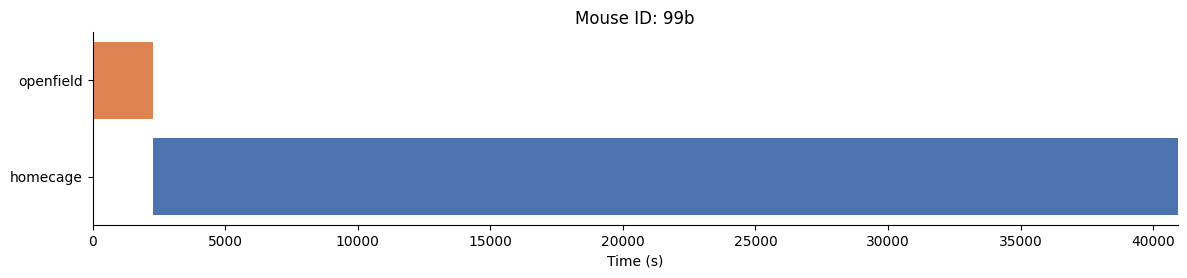

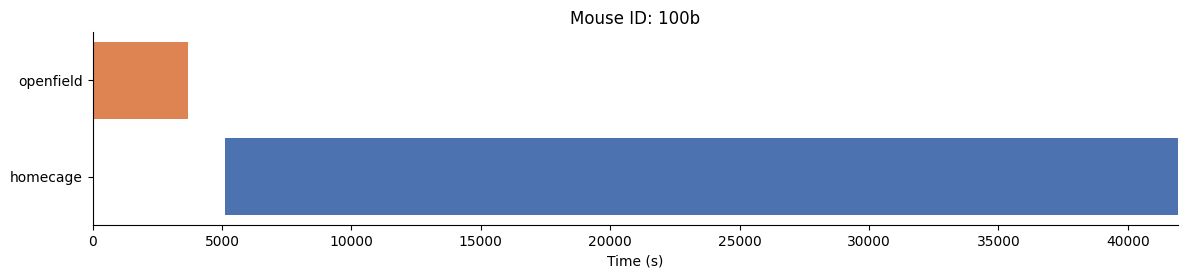

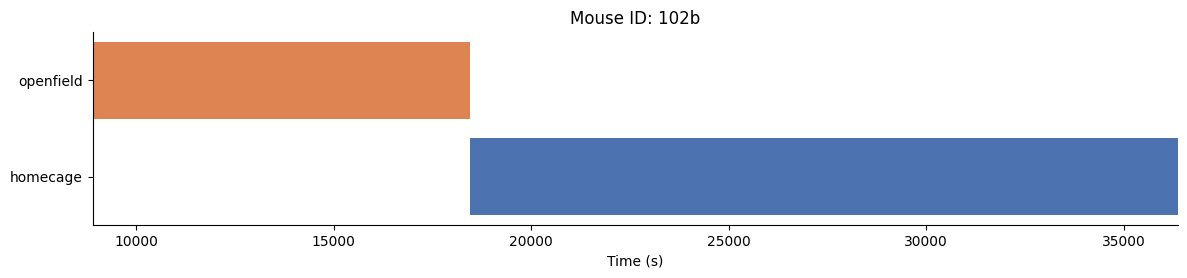

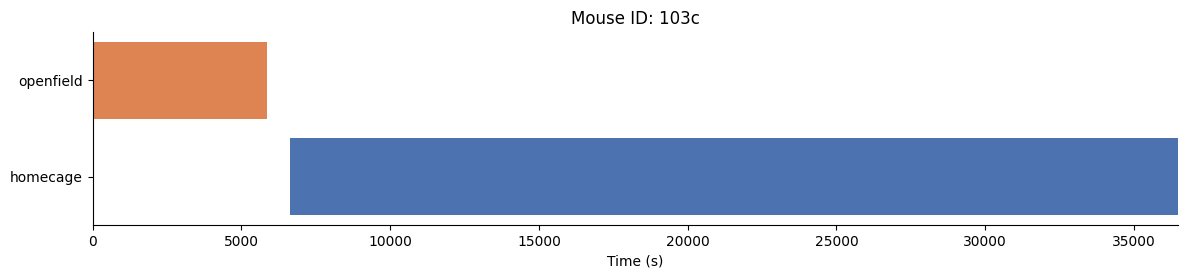

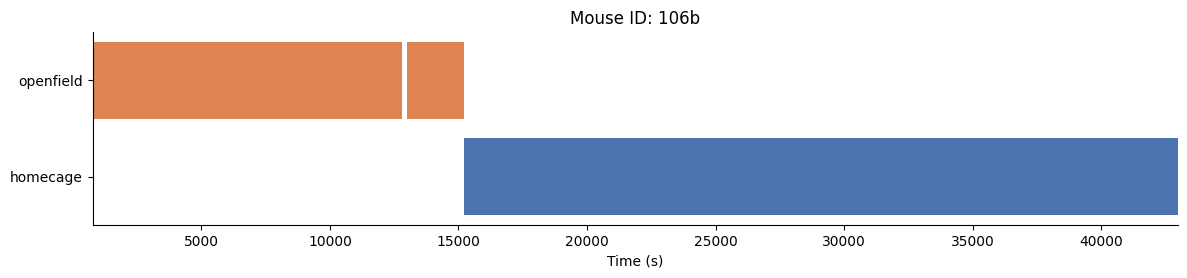

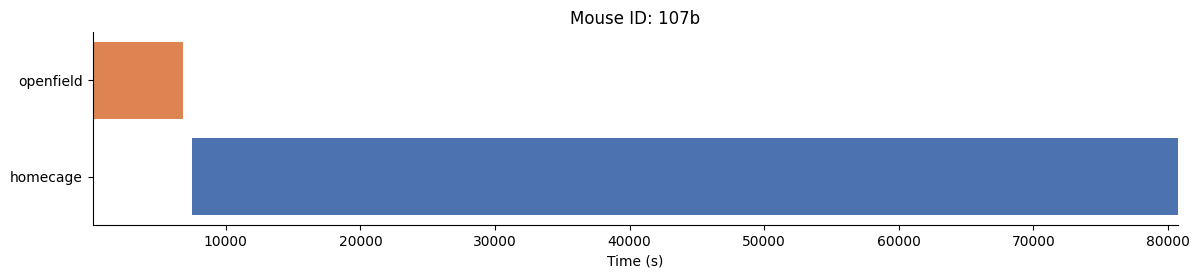

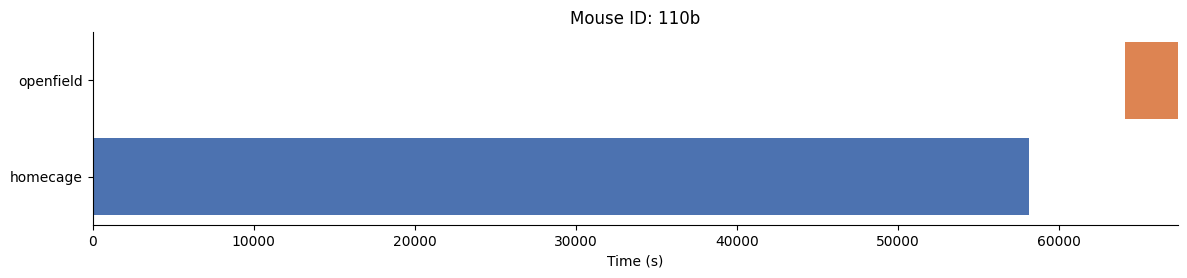

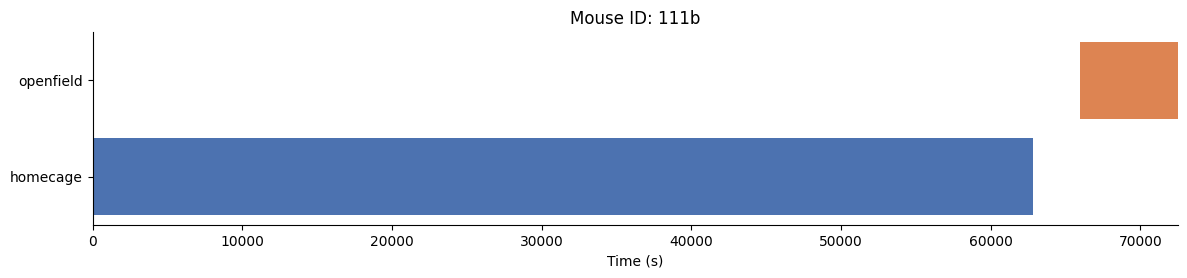

In [62]:
homecage = loadmat(RAW_DIR / "dual" / "homecage_periods.mat")['HomeCagePeriods'].squeeze()
openfield = loadmat(RAW_DIR / "dual" / "openfield_periods.mat")['OpenFieldPeriods'].squeeze()

for hc, of, mouse_id in zip(homecage, openfield, MOUSE_IDS_DUAL):
    intervals = np.vstack([hc, of])
    starts = intervals[:, 0]
    ends = intervals[:, 1]
    metadata = ['homecage' for _ in range(len(hc))] + ['openfield' for _ in range(len(of))]

    order = np.argsort(starts)
    starts = starts[order]
    ends = ends[order]
    metadata = [metadata[i] for i in order]

    session = nap.IntervalSet(start=starts, end=ends, time_units='s', metadata={'state': metadata})
    plot_intervals(session, column='state', title=f"Mouse ID: {mouse_id}")
    fname = PROCESSED_DIR / "dual" / mouse_id / "session.npz"
    print(f"Saving homecage/openfield periods to {fname}")
    session.save(fname)